In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsforecast import StatsForecast
from statsforecast.models import AutoETS, Naive

from pathlib import Path
import sys

import warnings
warnings.filterwarnings("ignore")

project_root = Path("..").resolve()

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

BASE_DIR = Path("../")

df = pd.read_csv(BASE_DIR/"data/raw/tp_outage_data(in).csv")

In [2]:
df.head()

,Unnamed: 0,CHANNEL,PG_NAME,CREATION_DATE,TOTAL_ATTEMPTED
0,6282,Myjio,CITIBANKUPI,6/23/2025 23:45,5219
1,6283,Myjio,CITIBANKUPI,6/24/2025 0:00,4980
2,6284,Myjio,CITIBANKUPI,6/24/2025 0:15,3174
3,6285,Myjio,CITIBANKUPI,6/24/2025 0:30,2174
4,6286,Myjio,CITIBANKUPI,6/24/2025 0:45,1422


In [3]:
df.nunique()

Unnamed: 0         6282
CHANNEL               1
PG_NAME               3
CREATION_DATE      2094
TOTAL_ATTEMPTED    2210
dtype: int64

In [4]:
df.shape

(6282, 5)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6282 entries, 0 to 6281
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Unnamed: 0       6282 non-null   int64 
 1   CHANNEL          6282 non-null   object
 2   PG_NAME          6282 non-null   object
 3   CREATION_DATE    6282 non-null   object
 4   TOTAL_ATTEMPTED  6282 non-null   int64 
dtypes: int64(2), object(3)
memory usage: 245.5+ KB


In [6]:
df.describe()

,Unnamed: 0,TOTAL_ATTEMPTED
count,6282.000000,6282.000000
mean,28926.500000,2651.460045
std,16396.091472,4610.049428
min,6282.000000,0.000000
25%,7852.250000,0.000000
50%,32460.500000,159.000000
75%,46466.750000,2464.500000
max,48037.000000,20658.000000


In [7]:
df["CREATION_DATE"] = pd.to_datetime(df["CREATION_DATE"])
df.dtypes

Unnamed: 0                  int64
CHANNEL                    object
PG_NAME                    object
CREATION_DATE      datetime64[ns]
TOTAL_ATTEMPTED             int64
dtype: object

In [8]:
df["CREATION_DATE"].max()

Timestamp('2025-07-15 19:00:00')

In [9]:
df["CREATION_DATE"].min()

Timestamp('2025-06-23 23:45:00')

In [10]:
df.isna().sum()

Unnamed: 0         0
CHANNEL            0
PG_NAME            0
CREATION_DATE      0
TOTAL_ATTEMPTED    0
dtype: int64

In [11]:
clean_df=df.copy()

In [12]:
clean_df

,Unnamed: 0,CHANNEL,PG_NAME,CREATION_DATE,TOTAL_ATTEMPTED
0,6282,Myjio,CITIBANKUPI,2025-06-23 23:45:00,5219
1,6283,Myjio,CITIBANKUPI,2025-06-24 00:00:00,4980
2,6284,Myjio,CITIBANKUPI,2025-06-24 00:15:00,3174
3,6285,Myjio,CITIBANKUPI,2025-06-24 00:30:00,2174
4,6286,Myjio,CITIBANKUPI,2025-06-24 00:45:00,1422
...,...,...,...,...,...
6277,48033,Myjio,YESBANKUPI,2025-07-15 18:00:00,282
6278,48034,Myjio,YESBANKUPI,2025-07-15 18:15:00,284
6279,48035,Myjio,YESBANKUPI,2025-07-15 18:30:00,278
6280,48036,Myjio,YESBANKUPI,2025-07-15 18:45:00,257


In [13]:
mapping = {"CITIBANKUPI": "A","PAYTMPGUPI": "B","YESBANKUPI": "C"}

clean_df["PG_NAME"] = clean_df["PG_NAME"].map(mapping)

In [14]:
clean_df.rename(columns={"PG_NAME": "unique_id","CREATION_DATE": "ds","TOTAL_ATTEMPTED": "y"}, inplace=True)

In [15]:
clean_df

,Unnamed: 0,CHANNEL,unique_id,ds,y
0,6282,Myjio,A,2025-06-23 23:45:00,5219
1,6283,Myjio,A,2025-06-24 00:00:00,4980
2,6284,Myjio,A,2025-06-24 00:15:00,3174
3,6285,Myjio,A,2025-06-24 00:30:00,2174
4,6286,Myjio,A,2025-06-24 00:45:00,1422
...,...,...,...,...,...
6277,48033,Myjio,C,2025-07-15 18:00:00,282
6278,48034,Myjio,C,2025-07-15 18:15:00,284
6279,48035,Myjio,C,2025-07-15 18:30:00,278
6280,48036,Myjio,C,2025-07-15 18:45:00,257


In [16]:
clean_df.dtypes

Unnamed: 0             int64
CHANNEL               object
unique_id             object
ds            datetime64[ns]
y                      int64
dtype: object

In [17]:
clean_df["unique_id"] = clean_df["unique_id"].astype("string")
clean_df["CHANNEL"] = clean_df["CHANNEL"].astype("string")

In [18]:
clean_df.dtypes

Unnamed: 0             int64
CHANNEL       string[python]
unique_id     string[python]
ds            datetime64[ns]
y                      int64
dtype: object

In [19]:
clean_df

,Unnamed: 0,CHANNEL,unique_id,ds,y
0,6282,Myjio,A,2025-06-23 23:45:00,5219
1,6283,Myjio,A,2025-06-24 00:00:00,4980
2,6284,Myjio,A,2025-06-24 00:15:00,3174
3,6285,Myjio,A,2025-06-24 00:30:00,2174
4,6286,Myjio,A,2025-06-24 00:45:00,1422
...,...,...,...,...,...
6277,48033,Myjio,C,2025-07-15 18:00:00,282
6278,48034,Myjio,C,2025-07-15 18:15:00,284
6279,48035,Myjio,C,2025-07-15 18:30:00,278
6280,48036,Myjio,C,2025-07-15 18:45:00,257


In [20]:
ts_df = (clean_df.groupby(["unique_id", "ds"], as_index=False)["y"].sum())

print(ts_df.head())

  unique_id                  ds     y
0         A 2025-06-23 23:45:00  5219
1         A 2025-06-24 00:00:00  4980
2         A 2025-06-24 00:15:00  3174
3         A 2025-06-24 00:30:00  2174
4         A 2025-06-24 00:45:00  1422


In [21]:
ts_df

,unique_id,ds,y
0,A,2025-06-23 23:45:00,5219
1,A,2025-06-24 00:00:00,4980
2,A,2025-06-24 00:15:00,3174
3,A,2025-06-24 00:30:00,2174
4,A,2025-06-24 00:45:00,1422
...,...,...,...
6277,C,2025-07-15 18:00:00,282
6278,C,2025-07-15 18:15:00,284
6279,C,2025-07-15 18:30:00,278
6280,C,2025-07-15 18:45:00,257


In [22]:
A_df = ts_df[ts_df["unique_id"] == "A"].copy()
B_df = ts_df[ts_df["unique_id"] == "B"].copy()
C_df = ts_df[ts_df["unique_id"] == "C"].copy()

In [23]:
A_df

,unique_id,ds,y
0,A,2025-06-23 23:45:00,5219
1,A,2025-06-24 00:00:00,4980
2,A,2025-06-24 00:15:00,3174
3,A,2025-06-24 00:30:00,2174
4,A,2025-06-24 00:45:00,1422
...,...,...,...
2089,A,2025-07-15 18:00:00,10955
2090,A,2025-07-15 18:15:00,11267
2091,A,2025-07-15 18:30:00,12012
2092,A,2025-07-15 18:45:00,12410


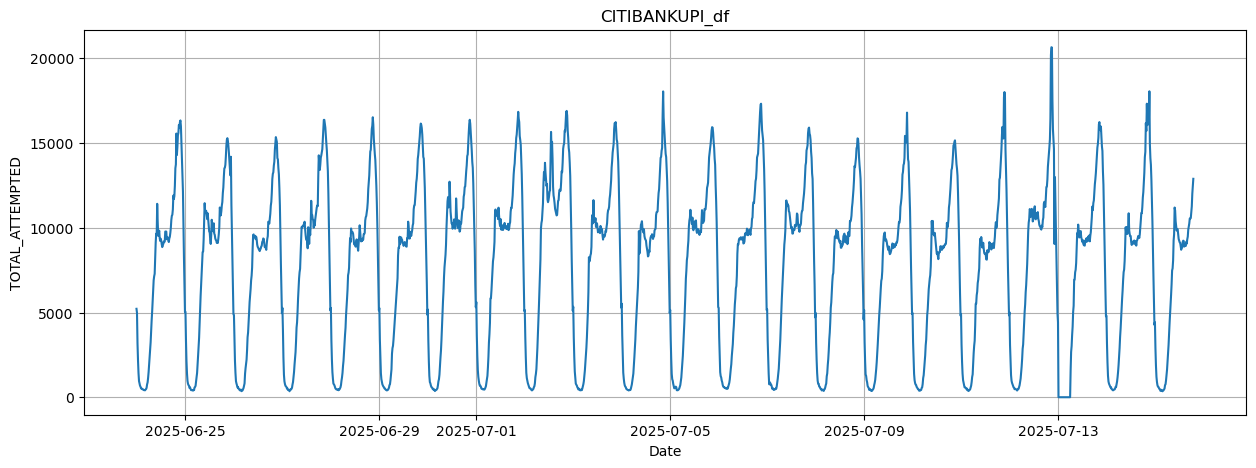

In [24]:
plt.figure(figsize=(15,5))

plt.plot(A_df["ds"], A_df["y"])

plt.title("CITIBANKUPI_df")
plt.xlabel("Date")
plt.ylabel("TOTAL_ATTEMPTED")
plt.grid(True)

plt.show()

In [25]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(A_df["y"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1]<0.05:
    print("Series is stationary")
else:
    print("Series isn't stationary")

ADF Statistic : -10.44244805177504
p-value : 1.5097042167760379e-18
Series is stationary


In [26]:
A_df["ds"] = pd.to_datetime(A_df["ds"])

expected = pd.date_range(start=A_df["ds"].min(),end=A_df["ds"].max(),freq="15min")

missing = expected.difference(A_df["ds"]) # finds missing value from expected list 

print(missing)

DatetimeIndex([], dtype='datetime64[ns]', freq='15min')


In [27]:
A_df[A_df["ds"]=="2025-07-09 00:15:00"]

,unique_id,ds,y
1442,A,2025-07-09 00:15:00,3250


In [28]:
A_df["y"].max()

20658

In [29]:
A_df[A_df["y"]==20658]["ds"]

1812   2025-07-12 20:45:00
Name: ds, dtype: datetime64[ns]

In [30]:
at_df=A_df.copy()

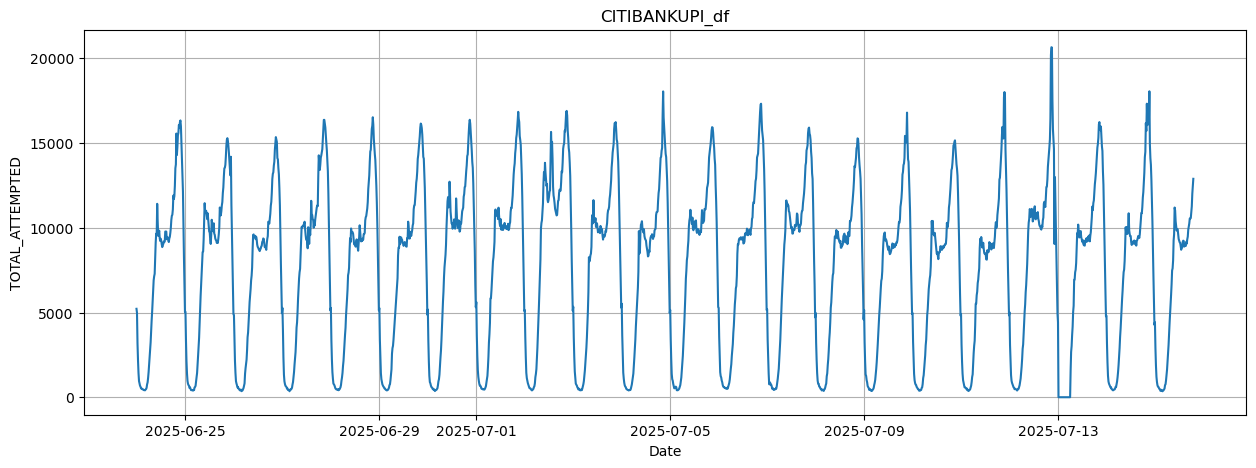

In [31]:
plt.figure(figsize=(15,5))

plt.plot(at_df["ds"], at_df["y"])

plt.title("CITIBANKUPI_df")
plt.xlabel("Date")
plt.ylabel("TOTAL_ATTEMPTED")
plt.grid(True)

plt.show()

In [ ]:
def _boundary_creation(df_count,sdval,mycol,mydcol,bucket,aggtype,iteration, value_format):
    df_count[mydcol]=df_count[mydcol].dt.floor(bucket) # this is used to keep time in 15 min freq
    df_count = (df_count.groupby(["unique_id", mydcol], as_index=False).agg({mycol: aggtype})) # used to group the same time data then use aggtype on the values to have only 1 value for same time 

    rolltype='dttime'
    df_count[rolltype]=df_count[mydcol].dt.time  # create new column which have only time from the value (no date only 00:00:00 format)
    mylst=list(df_count[rolltype].unique()) # save all unique times 

    for k in range(0,iteration):
        for i in range(len(mylst)):
            actualn=len(df_count[df_count[rolltype]==mylst[i]]) # counts the number of time from data
            df_count.loc[df_count[rolltype]==mylst[i],"AVG_"+mycol]=df_count[df_count[rolltype]==mylst[i]][mycol].agg({mycol:"mean"})[0] # calculate the average for each unique time , ex- at time 12:30:00 what is the average value 
        df_count["AVG_"+mycol] = df_count["AVG_"+mycol].fillna(0)
        df_count['AVG_'+mycol] = round(df_count["AVG_"+mycol], value_format)
        for i in range(len(mylst)):
            actualn=len(df_count[df_count[rolltype]==mylst[i]])
            df_count.loc[df_count[rolltype]==mylst[i],'sdval']=df_count[df_count[rolltype]==mylst[i]][mycol].agg({mycol:'std'})[0] # calculate the std for each unique time , ex- at time 12:30:00 what is the std value 
        df_count["sdval"] = df_count["sdval"].fillna(0)
        df_count["sdval"] = round(df_count["sdval"])
        #df_count['sdval']=round(df_count['sdval']).astype(int)
        df_count['LCL_'+ mycol]=round(df_count["AVG_"+mycol]-(sdval*df_count['sdval']), value_format)
        df_count['UCL_'+ mycol]=round(df_count["AVG_"+mycol]+(sdval*df_count['sdval']), value_format)
        df_count['LCL_'+ mycol] = df_count['LCL_'+ mycol].apply(lambda x: x if x >= 0 else 0)
        df_count["outlier"]=np.where((df_count[mycol]<df_count['LCL_'+ mycol]) | (df_count[mycol]>df_count['UCL_'+ mycol]),1,0)
        df_count[mycol]=np.where(df_count["outlier"]==1, df_count["AVG_"+mycol],df_count[mycol])
        if k!=iteration-1:
            df_count=df_count.iloc[:,:-5]      
    # print(df_count[df_count["outlier"] == 1][[mydcol, mycol, "AVG_"+mycol]])
    collst1=[rolltype,'LCL_'+ mycol, 'UCL_'+ mycol, 'AVG_'+mycol]
    final_df = df_count[collst1].drop_duplicates()
    print(final_df)
    return final_df,df_count

In [33]:
a_df,att_df=_boundary_creation(at_df,2,"y","ds","15min",sum,3,2)

      dttime     LCL_y     UCL_y     AVG_y
0   23:45:00   4672.93   5364.93   5018.93
1   00:00:00   4778.04   5458.04   5118.04
2   00:15:00   3033.15   3681.15   3357.15
3   00:30:00   2004.63   2472.63   2238.63
4   00:45:00   1260.92   1528.92   1394.92
..       ...       ...       ...       ...
91  22:30:00  11820.54  13504.54  12662.54
92  22:45:00  10337.57  12301.57  11319.57
93  23:00:00   8968.70  10596.70   9782.70
94  23:15:00   7420.04   8768.04   8094.04
95  23:30:00   6023.84   7123.84   6573.84

[96 rows x 4 columns]


In [34]:
from datetime import time
a_df[a_df["dttime"]==time(20, 45, 0)]

,dttime,LCL_y,UCL_y,AVG_y
84,20:45:00,14811.72,17287.72,16049.72


In [35]:
att_df

,unique_id,ds,y,dttime,AVG_y,sdval,LCL_y,UCL_y,outlier
0,A,2025-06-23 23:45:00,5219.0,23:45:00,5018.93,173.0,4672.93,5364.93,0
1,A,2025-06-24 00:00:00,4980.0,00:00:00,5118.04,170.0,4778.04,5458.04,0
2,A,2025-06-24 00:15:00,3174.0,00:15:00,3357.15,162.0,3033.15,3681.15,0
3,A,2025-06-24 00:30:00,2174.0,00:30:00,2238.63,117.0,2004.63,2472.63,0
4,A,2025-06-24 00:45:00,1422.0,00:45:00,1394.92,67.0,1260.92,1528.92,0
...,...,...,...,...,...,...,...,...,...
2089,A,2025-07-15 18:00:00,10955.0,18:00:00,11580.91,436.0,10708.91,12452.91,0
2090,A,2025-07-15 18:15:00,11267.0,18:15:00,11938.23,507.0,10924.23,12952.23,0
2091,A,2025-07-15 18:30:00,12012.0,18:30:00,12375.27,556.0,11263.27,13487.27,0
2092,A,2025-07-15 18:45:00,12410.0,18:45:00,12814.59,556.0,11702.59,13926.59,0


In [36]:
att_df[att_df["ds"]=="2025-07-12 20:45:00"]

,unique_id,ds,y,dttime,AVG_y,sdval,LCL_y,UCL_y,outlier
1812,A,2025-07-12 20:45:00,16259.19,20:45:00,16049.72,619.0,14811.72,17287.72,0


In [37]:
att_df["y"].max()

17274.0

In [38]:
A_df_clean=att_df[["unique_id","ds","y"]]

In [39]:
A_df_clean

,unique_id,ds,y
0,A,2025-06-23 23:45:00,5219.0
1,A,2025-06-24 00:00:00,4980.0
2,A,2025-06-24 00:15:00,3174.0
3,A,2025-06-24 00:30:00,2174.0
4,A,2025-06-24 00:45:00,1422.0
...,...,...,...
2089,A,2025-07-15 18:00:00,10955.0
2090,A,2025-07-15 18:15:00,11267.0
2091,A,2025-07-15 18:30:00,12012.0
2092,A,2025-07-15 18:45:00,12410.0


In [40]:
SPLIT_DATE = "2025-07-11 00:00:00"
FREQ = "15min"
SEASON_LENGTH = 96

train = A_df_clean[A_df_clean.ds <= SPLIT_DATE].copy()
valid = A_df_clean[A_df_clean.ds > SPLIT_DATE].copy()

total_train_weeks = train["ds"].nunique()
print(f"Expected weeks in training set: {total_train_weeks}")


Expected weeks in training set: 1634


In [41]:
train

,unique_id,ds,y
0,A,2025-06-23 23:45:00,5219.0
1,A,2025-06-24 00:00:00,4980.0
2,A,2025-06-24 00:15:00,3174.0
3,A,2025-06-24 00:30:00,2174.0
4,A,2025-06-24 00:45:00,1422.0
...,...,...,...
1629,A,2025-07-10 23:00:00,9434.0
1630,A,2025-07-10 23:15:00,7766.0
1631,A,2025-07-10 23:30:00,6105.0
1632,A,2025-07-10 23:45:00,4817.0


In [42]:

sf = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH, model="MMM")],freq=FREQ,fallback_model=Naive(),n_jobs=-1)

sf.fit(train)
print("Training completed")


Training completed


In [43]:

h = valid["ds"].nunique()
print(f"Forecasting horizon: {h} weeks")

forecast = sf.predict(h=h)
print(forecast.head())


Forecasting horizon: 460 weeks
  unique_id                  ds      AutoETS
0         A 2025-07-11 00:15:00  3265.140930
1         A 2025-07-11 00:30:00  2178.686305
2         A 2025-07-11 00:45:00  1358.952847
3         A 2025-07-11 01:00:00  1006.800850
4         A 2025-07-11 01:15:00   822.704767


In [44]:

results_clean = valid.merge(forecast, on=["unique_id", "ds"])

mae = np.mean(np.abs(results_clean["y"] - results_clean["AutoETS"]))
rmse = np.sqrt(np.mean((results_clean["y"] - results_clean["AutoETS"])**2))
wmape = (np.abs(results_clean["y"] - results_clean["AutoETS"]).sum() / np.abs(results_clean["y"]).sum()) * 100
accuracy = 100 - wmape

print("--- Cleaned Model Evaluation ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WMAPE: {wmape:.2f}%")
print(f"Overall Accuracy: {accuracy:.2f}%")


--- Cleaned Model Evaluation ---
MAE:  357.05
RMSE: 531.70
WMAPE: 4.78%
Overall Accuracy: 95.22%


In [45]:
results_clean

,unique_id,ds,y,AutoETS
0,A,2025-07-11 00:15:00,3107.0,3265.140930
1,A,2025-07-11 00:30:00,2093.0,2178.686305
2,A,2025-07-11 00:45:00,1391.0,1358.952847
3,A,2025-07-11 01:00:00,1010.0,1006.800850
4,A,2025-07-11 01:15:00,849.0,822.704767
...,...,...,...,...
455,A,2025-07-15 18:00:00,10955.0,11115.265213
456,A,2025-07-15 18:15:00,11267.0,11450.841990
457,A,2025-07-15 18:30:00,12012.0,11873.074935
458,A,2025-07-15 18:45:00,12410.0,12283.263916


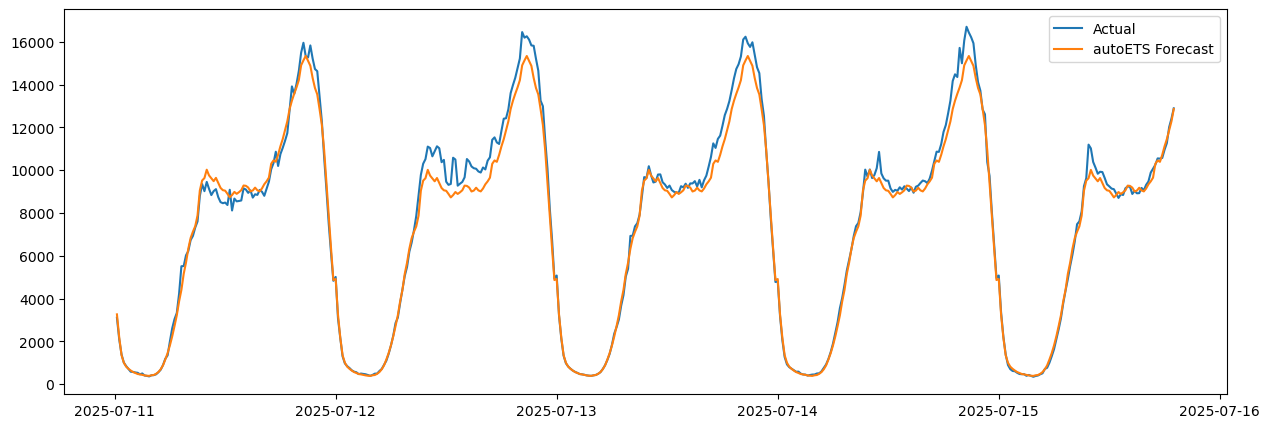

In [46]:

actual = results_clean.copy()

plt.figure(figsize=(15,5))

plt.plot(actual["ds"],actual["y"],label="Actual")

plt.plot(actual["ds"],actual["AutoETS"],label="autoETS Forecast")

plt.legend()

plt.show()

# C (YESBANKUPI) series

In [47]:
C_df

,unique_id,ds,y
4188,C,2025-06-23 23:45:00,77
4189,C,2025-06-24 00:00:00,64
4190,C,2025-06-24 00:15:00,65
4191,C,2025-06-24 00:30:00,33
4192,C,2025-06-24 00:45:00,44
...,...,...,...
6277,C,2025-07-15 18:00:00,282
6278,C,2025-07-15 18:15:00,284
6279,C,2025-07-15 18:30:00,278
6280,C,2025-07-15 18:45:00,257


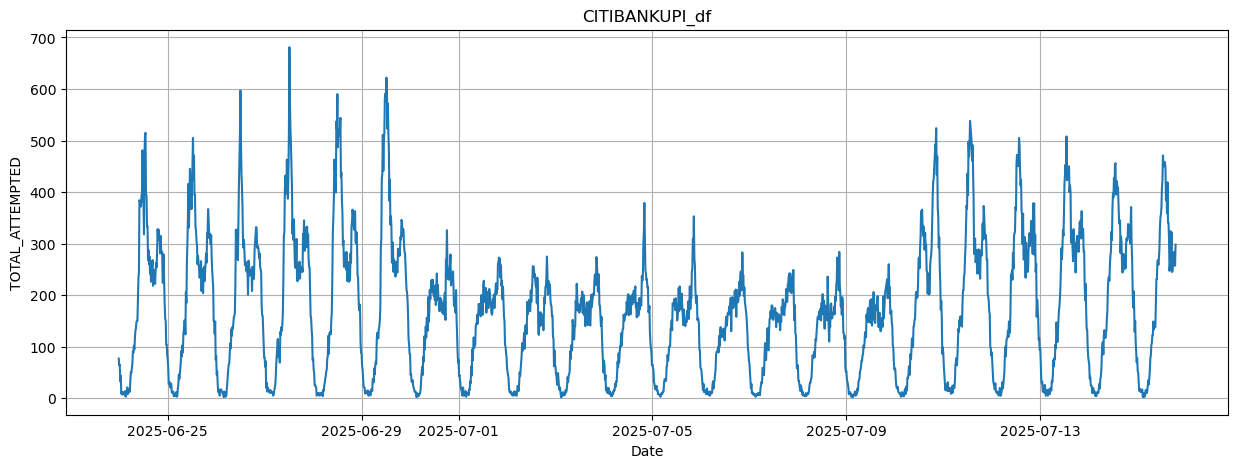

In [48]:
plt.figure(figsize=(15,5))

plt.plot(C_df["ds"], C_df["y"])

plt.title("CITIBANKUPI_df")
plt.xlabel("Date")
plt.ylabel("TOTAL_ATTEMPTED")
plt.grid(True)

plt.show()

In [49]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(C_df["y"])

print("ADF Statistic :", result[0])
print("p-value :", result[1])

if result[1]<0.05:
    print("Series is stationary")
else:
    print("Series isn't stationary")

ADF Statistic : -9.128708069108686
p-value : 3.0633513770299203e-15
Series is stationary


In [50]:
C_df["ds"] = pd.to_datetime(C_df["ds"])

expected = pd.date_range(start=C_df["ds"].min(),end=C_df["ds"].max(),freq="15min")

missing = expected.difference(C_df["ds"]) # finds missing value from expected list 

print(missing)

DatetimeIndex([], dtype='datetime64[ns]', freq='15min')


In [51]:
ct_df=C_df.copy()

In [52]:
report,ct_df= _boundary_creation(ct_df,2,"y","ds","15min",sum,3,2)

      dttime   LCL_y   UCL_y   AVG_y
0   23:45:00   47.64   99.64   73.64
1   00:00:00   49.05   97.05   73.05
2   00:15:00   40.92   72.92   56.92
3   00:30:00   26.20   58.20   42.20
4   00:45:00   17.00   45.00   31.00
..       ...     ...     ...     ...
91  22:30:00  125.14  233.14  179.14
92  22:45:00  114.18  190.18  152.18
93  23:00:00   90.86  190.86  140.86
94  23:15:00   82.70  138.70  110.70
95  23:30:00   63.75  123.75   93.75

[96 rows x 4 columns]


In [53]:
ct_df

,unique_id,ds,y,dttime,AVG_y,sdval,LCL_y,UCL_y,outlier
0,C,2025-06-23 23:45:00,77.0,23:45:00,73.64,13.0,47.64,99.64,0
1,C,2025-06-24 00:00:00,64.0,00:00:00,73.05,12.0,49.05,97.05,0
2,C,2025-06-24 00:15:00,65.0,00:15:00,56.92,8.0,40.92,72.92,0
3,C,2025-06-24 00:30:00,33.0,00:30:00,42.20,8.0,26.20,58.20,0
4,C,2025-06-24 00:45:00,44.0,00:45:00,31.00,7.0,17.00,45.00,0
...,...,...,...,...,...,...,...,...,...
2089,C,2025-07-15 18:00:00,282.0,18:00:00,227.32,51.0,125.32,329.32,0
2090,C,2025-07-15 18:15:00,284.0,18:15:00,234.91,50.0,134.91,334.91,0
2091,C,2025-07-15 18:30:00,278.0,18:30:00,244.05,51.0,142.05,346.05,0
2092,C,2025-07-15 18:45:00,257.0,18:45:00,238.55,44.0,150.55,326.55,0


In [54]:
ct_df["y"].max()

612.0

In [55]:
C_df["y"].max()

681

In [56]:
C_df_clean=ct_df[["unique_id","ds","y"]]

In [57]:
C_df_clean

,unique_id,ds,y
0,C,2025-06-23 23:45:00,77.0
1,C,2025-06-24 00:00:00,64.0
2,C,2025-06-24 00:15:00,65.0
3,C,2025-06-24 00:30:00,33.0
4,C,2025-06-24 00:45:00,44.0
...,...,...,...
2089,C,2025-07-15 18:00:00,282.0
2090,C,2025-07-15 18:15:00,284.0
2091,C,2025-07-15 18:30:00,278.0
2092,C,2025-07-15 18:45:00,257.0


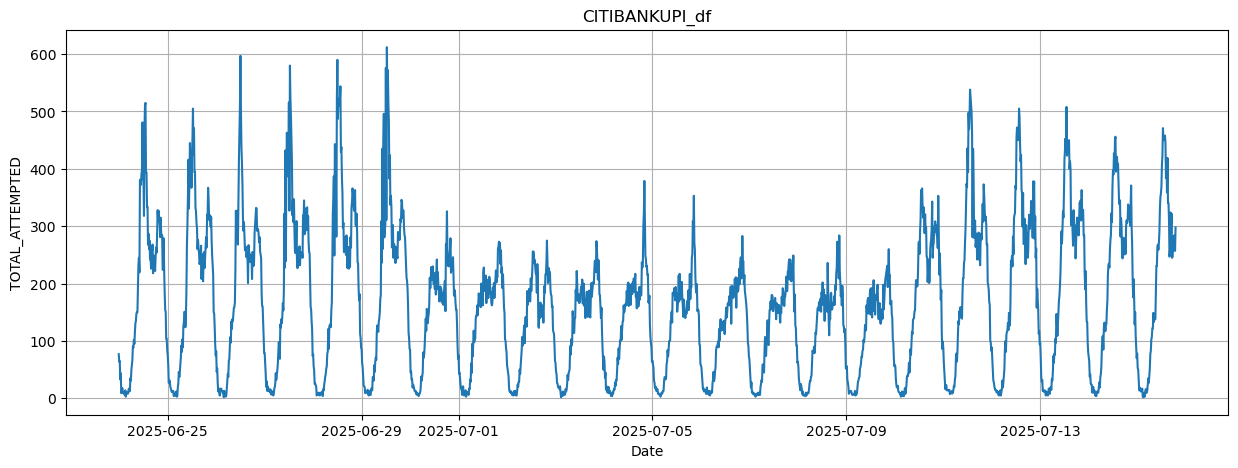

In [58]:
plt.figure(figsize=(15,5))

plt.plot(C_df_clean["ds"], C_df_clean["y"])

plt.title("CITIBANKUPI_df")
plt.xlabel("Date")
plt.ylabel("TOTAL_ATTEMPTED")
plt.grid(True)

plt.show()

In [59]:
SPLIT_DATE = "2025-07-11 00:00:00"
FREQ = "15min"
SEASON_LENGTH = 96

train_c = C_df_clean[C_df_clean.ds <= SPLIT_DATE].copy()
valid_c = C_df_clean[C_df_clean.ds > SPLIT_DATE].copy()

total_train_weeks = train_c["ds"].nunique()
print(f"Expected weeks in training set: {total_train_weeks}")

Expected weeks in training set: 1634


In [60]:
sf_c = StatsForecast(models=[AutoETS(season_length=SEASON_LENGTH, model="MMM")],freq=FREQ,fallback_model=Naive(),n_jobs=-1)

sf_c.fit(train_c)
print("Training completed")

Training completed


In [61]:
h = valid_c["ds"].nunique()
print(f"Forecasting horizon: {h} weeks")

forecast = sf_c.predict(h=h)
print(forecast.head())

Forecasting horizon: 460 weeks
  unique_id                  ds    AutoETS
0         C 2025-07-11 00:15:00  56.213815
1         C 2025-07-11 00:30:00  42.054454
2         C 2025-07-11 00:45:00  30.737557
3         C 2025-07-11 01:00:00  23.143410
4         C 2025-07-11 01:15:00  17.302019


In [62]:
results_clean = valid_c.merge(forecast, on=["unique_id", "ds"])

mae = np.mean(np.abs(results_clean["y"] - results_clean["AutoETS"]))
rmse = np.sqrt(np.mean((results_clean["y"] - results_clean["AutoETS"])**2))
wmape = (np.abs(results_clean["y"] - results_clean["AutoETS"]).sum() / np.abs(results_clean["y"]).sum()) * 100
accuracy = 100 - wmape

print("--- Cleaned Model Evaluation ---")
print(f"MAE:  {mae:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"WMAPE: {wmape:.2f}%")
print(f"Overall Accuracy: {accuracy:.2f}%")

--- Cleaned Model Evaluation ---
MAE:  38.43
RMSE: 63.40
WMAPE: 18.87%
Overall Accuracy: 81.13%


In [63]:
# from statsforecast.models import AutoARIMA
# sf_ca = StatsForecast(models=[AutoARIMA()],freq=FREQ,fallback_model=Naive(),n_jobs=-1)

# sf_ca.fit(train_c)
# print("Training completed")

In [64]:
# h = valid_c["ds"].nunique()
# print(f"Forecasting horizon: {h} weeks")

# forecast = sf_ca.predict(h=h)
# print(forecast.head())

In [65]:
# results_clean = valid_c.merge(forecast, on=["unique_id", "ds"])

# mae = np.mean(np.abs(results_clean["y"] - results_clean["AutoARIMA"]))
# rmse = np.sqrt(np.mean((results_clean["y"] - results_clean["AutoARIMA"])**2))
# wmape = (np.abs(results_clean["y"] - results_clean["AutoARIMA"]).sum() / np.abs(results_clean["y"]).sum()) * 100
# accuracy = 100 - wmape

# print("--- Cleaned Model Evaluation ---")
# print(f"MAE:  {mae:.2f}")
# print(f"RMSE: {rmse:.2f}")
# print(f"WMAPE: {wmape:.2f}%")
# print(f"Overall Accuracy: {accuracy:.2f}%")

In [66]:
results_clean

,unique_id,ds,y,AutoETS
0,C,2025-07-11 00:15:00,63.0,56.213815
1,C,2025-07-11 00:30:00,46.0,42.054454
2,C,2025-07-11 00:45:00,32.0,30.737557
3,C,2025-07-11 01:00:00,16.0,23.143410
4,C,2025-07-11 01:15:00,23.0,17.302019
...,...,...,...,...
455,C,2025-07-15 18:00:00,282.0,246.231974
456,C,2025-07-15 18:15:00,284.0,260.397871
457,C,2025-07-15 18:30:00,278.0,266.461823
458,C,2025-07-15 18:45:00,257.0,259.804735


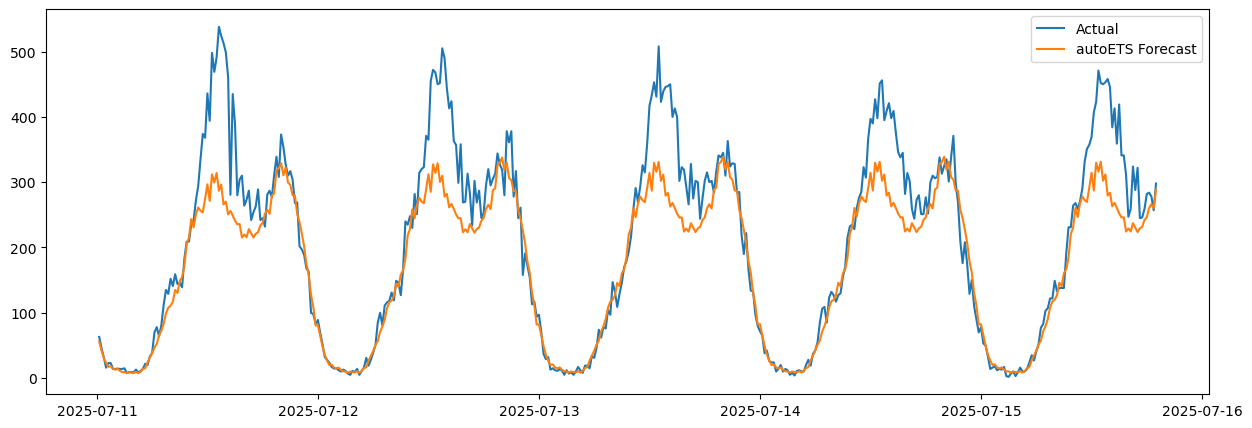

In [67]:

actual = results_clean.copy()

plt.figure(figsize=(15,5))

plt.plot(actual["ds"],actual["y"],label="Actual")

plt.plot(actual["ds"],actual["AutoETS"],label="autoETS Forecast")

plt.legend()

plt.show()

# C series using RandomForest 

In [68]:
train_f=train_c.copy()
test_f=valid_c.copy()

In [69]:
train_f["Year"] = train_f["ds"].dt.year
train_f["Month"] = train_f["ds"].dt.month
train_f["Week"] = train_f["ds"].dt.isocalendar().week.astype(int)
train_f["Day"] = train_f["ds"].dt.day
train_f["Hour"] = train_f["ds"].dt.hour
train_f["Minute"] = train_f["ds"].dt.minute

In [70]:
test_f["Year"] = test_f["ds"].dt.year
test_f["Month"] = test_f["ds"].dt.month
test_f["Week"] = test_f["ds"].dt.isocalendar().week.astype(int)
test_f["Day"] = test_f["ds"].dt.day
test_f["Hour"] = test_f["ds"].dt.hour
test_f["Minute"] = test_f["ds"].dt.minute

In [71]:
train_f

,unique_id,ds,y,Year,Month,Week,Day,Hour,Minute
0,C,2025-06-23 23:45:00,77.00,2025,6,26,23,23,45
1,C,2025-06-24 00:00:00,64.00,2025,6,26,24,0,0
2,C,2025-06-24 00:15:00,65.00,2025,6,26,24,0,15
3,C,2025-06-24 00:30:00,33.00,2025,6,26,24,0,30
4,C,2025-06-24 00:45:00,44.00,2025,6,26,24,0,45
...,...,...,...,...,...,...,...,...,...
1629,C,2025-07-10 23:00:00,189.00,2025,7,28,10,23,0
1630,C,2025-07-10 23:15:00,112.85,2025,7,28,10,23,15
1631,C,2025-07-10 23:30:00,86.00,2025,7,28,10,23,30
1632,C,2025-07-10 23:45:00,99.00,2025,7,28,10,23,45


In [72]:
test_f

,unique_id,ds,y,Year,Month,Week,Day,Hour,Minute
1634,C,2025-07-11 00:15:00,63.0,2025,7,28,11,0,15
1635,C,2025-07-11 00:30:00,46.0,2025,7,28,11,0,30
1636,C,2025-07-11 00:45:00,32.0,2025,7,28,11,0,45
1637,C,2025-07-11 01:00:00,16.0,2025,7,28,11,1,0
1638,C,2025-07-11 01:15:00,23.0,2025,7,28,11,1,15
...,...,...,...,...,...,...,...,...,...
2089,C,2025-07-15 18:00:00,282.0,2025,7,29,15,18,0
2090,C,2025-07-15 18:15:00,284.0,2025,7,29,15,18,15
2091,C,2025-07-15 18:30:00,278.0,2025,7,29,15,18,30
2092,C,2025-07-15 18:45:00,257.0,2025,7,29,15,18,45


In [73]:
y_train=train_f["y"]

In [74]:
y_train

0        77.00
1        64.00
2        65.00
3        33.00
4        44.00
         ...  
1629    189.00
1630    112.85
1631     86.00
1632     99.00
1633     88.00
Name: y, Length: 1634, dtype: float64

In [75]:
train_f

,unique_id,ds,y,Year,Month,Week,Day,Hour,Minute
0,C,2025-06-23 23:45:00,77.00,2025,6,26,23,23,45
1,C,2025-06-24 00:00:00,64.00,2025,6,26,24,0,0
2,C,2025-06-24 00:15:00,65.00,2025,6,26,24,0,15
3,C,2025-06-24 00:30:00,33.00,2025,6,26,24,0,30
4,C,2025-06-24 00:45:00,44.00,2025,6,26,24,0,45
...,...,...,...,...,...,...,...,...,...
1629,C,2025-07-10 23:00:00,189.00,2025,7,28,10,23,0
1630,C,2025-07-10 23:15:00,112.85,2025,7,28,10,23,15
1631,C,2025-07-10 23:30:00,86.00,2025,7,28,10,23,30
1632,C,2025-07-10 23:45:00,99.00,2025,7,28,10,23,45


In [76]:
train_f.drop("y",axis=1,inplace=True)
train_f.drop("unique_id",axis=1,inplace=True)
train_f.drop("ds",axis=1,inplace=True)

In [77]:
train_f

,Year,Month,Week,Day,Hour,Minute
0,2025,6,26,23,23,45
1,2025,6,26,24,0,0
2,2025,6,26,24,0,15
3,2025,6,26,24,0,30
4,2025,6,26,24,0,45
...,...,...,...,...,...,...
1629,2025,7,28,10,23,0
1630,2025,7,28,10,23,15
1631,2025,7,28,10,23,30
1632,2025,7,28,10,23,45


In [78]:
X_train=train_f

In [79]:
X_train

,Year,Month,Week,Day,Hour,Minute
0,2025,6,26,23,23,45
1,2025,6,26,24,0,0
2,2025,6,26,24,0,15
3,2025,6,26,24,0,30
4,2025,6,26,24,0,45
...,...,...,...,...,...,...
1629,2025,7,28,10,23,0
1630,2025,7,28,10,23,15
1631,2025,7,28,10,23,30
1632,2025,7,28,10,23,45


In [80]:
y_val=test_f["y"]

In [81]:
y_val

1634     63.0
1635     46.0
1636     32.0
1637     16.0
1638     23.0
        ...  
2089    282.0
2090    284.0
2091    278.0
2092    257.0
2093    298.0
Name: y, Length: 460, dtype: float64

In [82]:
test_f.drop("y",axis=1,inplace=True)
test_f.drop("unique_id",axis=1,inplace=True)
test_f.drop("ds",axis=1,inplace=True)

In [83]:
test_f

,Year,Month,Week,Day,Hour,Minute
1634,2025,7,28,11,0,15
1635,2025,7,28,11,0,30
1636,2025,7,28,11,0,45
1637,2025,7,28,11,1,0
1638,2025,7,28,11,1,15
...,...,...,...,...,...,...
2089,2025,7,29,15,18,0
2090,2025,7,29,15,18,15
2091,2025,7,29,15,18,30
2092,2025,7,29,15,18,45


In [84]:
X_val=test_f

In [85]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error
# baseline_preds = X_val["Lag_1"]
# baseline_mae = mean_absolute_error(y_val, baseline_preds)
# print(f"Naive Baseline (Lag-1) MAE: {baseline_mae:.2f}")
# {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
rf = RandomForestRegressor(n_estimators=500, max_depth=20, random_state=42, n_jobs=-1, max_features= "sqrt", min_samples_leaf= 2, min_samples_split= 2)
rf.fit(X_train, y_train)

preds = rf.predict(X_val)
model_mae = mean_absolute_error(y_val, preds)
print(f"Random Forest Regressor Validation MAE: {model_mae:.2f}")


Random Forest Regressor Validation MAE: 49.82


In [86]:
wmape = (np.sum(np.abs(y_val - preds)) / np.sum(y_val)) * 100

accuracy = 100 - wmape

print("MODEL PERFORMANCE IN PERCENTAGE:")
print(f"Weighted Error (wMAPE): {wmape:.2f}%")
print(f"Forecasting Accuracy:   {accuracy:.2f}%")


MODEL PERFORMANCE IN PERCENTAGE:
Weighted Error (wMAPE): 24.47%
Forecasting Accuracy:   75.53%


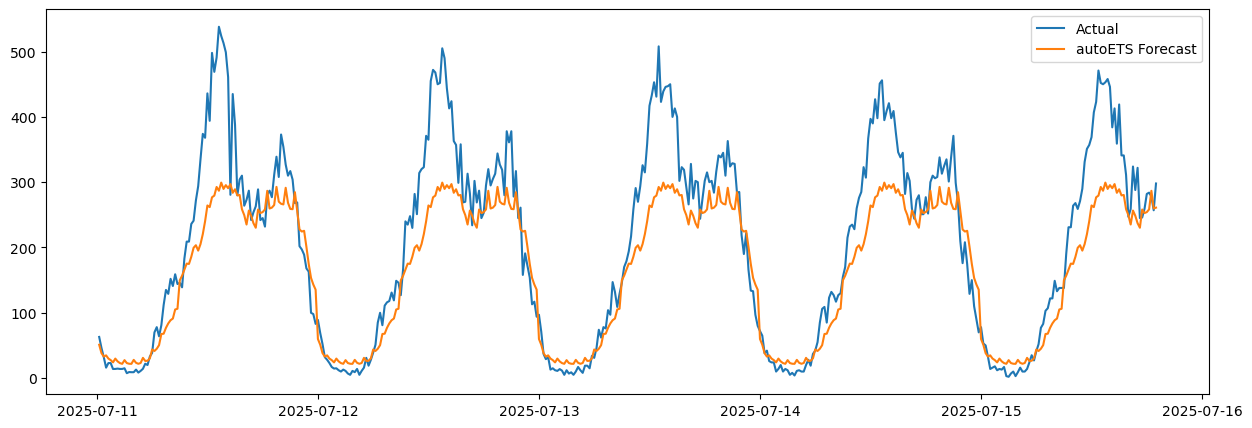

In [87]:

actual = results_clean.copy()

plt.figure(figsize=(15,5))

plt.plot(actual["ds"],y_val,label="Actual")

plt.plot(actual["ds"],preds,label="autoETS Forecast")

plt.legend()

plt.show()